In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [2]:
def load_data(filename):
    data = np.loadtxt(filename, delimiter=',')
    X = data[:,:2]
    y = data[:,2]
    return X, y

In [3]:
# load dataset
X_train, y_train = load_data("data/ex2data1.txt")

In [4]:
print("Five elements in X_train are:\n", X_train[5:10])
print("Type of X_train:",type(X_train))

Five elements in X_train are:
 [[45.08327748 56.31637178]
 [61.10666454 96.51142588]
 [75.02474557 46.55401354]
 [76.0987867  87.42056972]
 [84.43281996 43.53339331]]
Type of X_train: <class 'numpy.ndarray'>


In [5]:
print("Five elements in y_train are:\n", y_train[5:10])
print("Type of y_train:",type(y_train))

Five elements in y_train are:
 [0. 1. 1. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


In [6]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


In [7]:
def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0

    # Plot examples
    plt.plot(X[positive, 0], X[positive, 1], 'b*', label=pos_label)
    plt.plot(X[negative, 0], X[negative, 1], 'ro', label=neg_label)

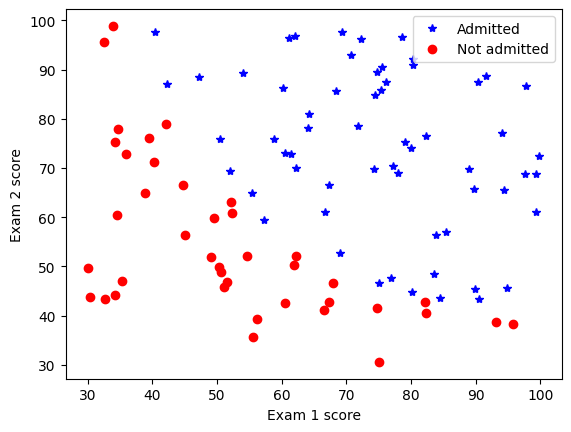

In [8]:
# Plot examples
plot_data(X_train, y_train, pos_label="Admitted", neg_label="Not admitted")

# Set the y-axis label
plt.ylabel('Exam 2 score')
# Set the x-axis label
plt.xlabel('Exam 1 score')
plt.legend(loc="upper right")
plt.show()

# EXO1

In [9]:
def sigmoid(z):

    ## START CODE HERE ##

    g = 1 / (1 + np.exp(-z))
    
    ## END SOLUTION ##

    return g

# TEST EXO1

In [10]:
print ("sigmoid(0) = " + str(sigmoid(0)))

sigmoid(0) = 0.5


In [11]:
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]


# EXO2

In [12]:
def compute_cost(X, y, w, b, lambda_= 1):
  m, n = X.shape

  ## START CODE HERE ##

  z = np.dot(X, w) + b
  f = sigmoid(z)
  loss = (-y * np.log(f)) - (1 - y) * np.log(1 - f)
  total_cost = loss.sum() / m
  
  ## END CODE HERE ##

  return total_cost

# TEST EXO2

In [13]:
m, n = X_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


In [14]:
# Compute and display cost with non-zero w
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost(X_train, y_train, test_w, test_b)

print('Cost at test w,b: {:.3f}'.format(cost))

Cost at test w,b: 0.218


# EXO3

In [15]:
def compute_gradient(X, y, w, b, lambda_=None):
    m, n = X.shape

    ## START CODE HERE ##

    z = np.dot(X, w) + b
    f = sigmoid(z)
    e = (f - y)
    dj_dw = np.dot(e,X) / m
    dj_db = e.sum() / m

    ## END CODE HERE ##

    return dj_db, dj_dw

# TEST EXO3

In [16]:
# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.1
dj_dw at initial w (zeros):[-12.009216589291151, -11.262842205513593]


In [17]:
# Compute and display cost and gradient with non-zero w
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw  = compute_gradient(X_train, y_train, test_w, test_b)

print('dj_db at test_w:', dj_db)
print('dj_dw at test_w:', dj_dw.tolist())

dj_db at test_w: -0.5999999999991071
dj_dw at test_w: [-44.83135361787378, -44.37384124953978]


# Learning parameters :

In [18]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    # number of training examples
    m = len(X)

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw
        b_in = b_in - alpha * dj_db

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)


        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

In [19]:
initial_w = np.array([-0.00082978,  0.00220324])
initial_b = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history,_ = gradient_descent(X_train ,y_train, initial_w, initial_b,compute_cost, compute_gradient, alpha, iterations, 0)
print(f"b,w found by gradient descent: {b:0.2f},{w} ")

Iteration    0: Cost     0.96   
Iteration 1000: Cost     0.31   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   
b,w found by gradient descent: -8.19,[0.07125355 0.06482888] 


# Plotting the decision boundary

In [20]:
def plot_decision_boundary(w, b, X, y):
    # Credit to dibgerge on Github for this plotting code

    plot_data(X[:, 0:2], y)

    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)

        plt.plot(plot_x, plot_y, c="b")

    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)

        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = sigmoid(np.dot(map_feature(u[i], v[j]).ravel(), w) + b)

        # important to transpose z before calling contour
        z = z.T

        # Plot z = 0
        plt.contour(u,v,z, levels = [0.5], colors="g")

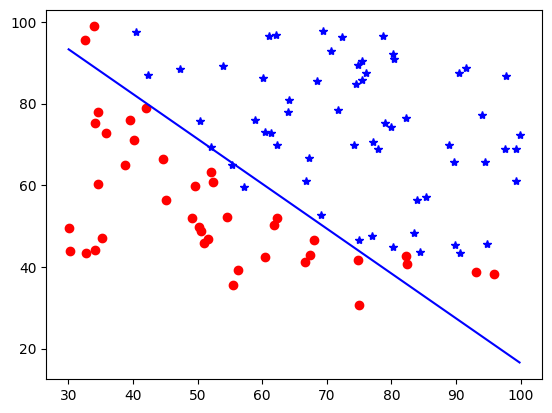

In [21]:
plot_decision_boundary(w, b, X_train, y_train)

# EXO4

In [22]:
def predict(X, w, b):

    ## START CODE HERE ##

    z = np.dot(X, w) + b
    f = sigmoid(z)
    p = (f >= 0.5).astype(int)

    ## END CODE HERE ##
    return p

# TEST EXO4

In [23]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

Output of predict: shape (4,), value [0 1 1 1]


In [24]:
#Compute accuracy on our training set
p = predict(X_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 92.000000


# REGULARIZATION

In [25]:
# load dataset
X_train, y_train = load_data("data/ex2data2.txt")

In [26]:
# print X_train
print("X_train:", X_train[:5])
print("Type of X_train:",type(X_train))

# print y_train
print("y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

X_train: [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]
Type of X_train: <class 'numpy.ndarray'>
y_train: [1. 1. 1. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


In [27]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (118, 2)
The shape of y_train is: (118,)
We have m = 118 training examples


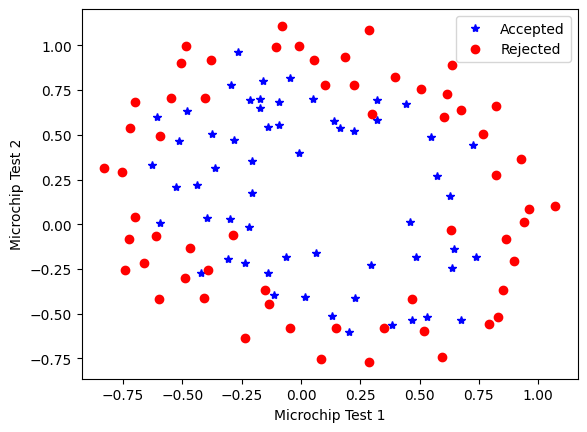

In [28]:
# Plot examples
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

# Set the y-axis label
plt.ylabel('Microchip Test 2')
# Set the x-axis label
plt.xlabel('Microchip Test 1')
plt.legend(loc="upper right")
plt.show()

- Better separation
- Lower training error
- Complex curves

In [29]:
def map_feature(X1, X2):
    """
    Feature mapping function to polynomial features
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    degree = 6
    out = []
    for i in range(1, degree+1):  # generates all combinations of degree 6
        for j in range(i + 1):
            out.append((X1**(i-j) * (X2**j)))  
    return np.stack(out, axis=1)

In [30]:
print("Original shape of data:", X_train.shape)

mapped_X =  map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", mapped_X.shape)

Original shape of data: (118, 2)
Shape after feature mapping: (118, 27)


In [31]:
print("X_train[0]:", X_train[0])
print("mapped X_train[0]:", mapped_X[0])

X_train[0]: [0.051267 0.69956 ]
mapped X_train[0]: [5.12670000e-02 6.99560000e-01 2.62830529e-03 3.58643425e-02
 4.89384194e-01 1.34745327e-04 1.83865725e-03 2.50892595e-02
 3.42353606e-01 6.90798869e-06 9.42624411e-05 1.28625106e-03
 1.75514423e-02 2.39496889e-01 3.54151856e-07 4.83255257e-06
 6.59422333e-05 8.99809795e-04 1.22782870e-02 1.67542444e-01
 1.81563032e-08 2.47750473e-07 3.38066048e-06 4.61305487e-05
 6.29470940e-04 8.58939846e-03 1.17205992e-01]


# EXO5

In [32]:
def compute_cost_reg(X, y, w, b, lambda_ = 1):
    m, n = X.shape

    # Calls the compute_cost function that you implemented above
    cost_without_reg = compute_cost(X, y, w, b)

    ## START CODE HERE ##

    reg_cost = cost_without_reg + (w**2).sum() * (lambda_ / (2 * m))

    ## END CODE HERE ##


    return reg_cost

# TEST EXO5

In [33]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print("Regularized cost :", cost)

Regularized cost : 0.6618252552483951


# EXO6

In [34]:
def compute_gradient_reg(X, y, w, b, lambda_ = 1):
    m, n = X.shape

    ## START CODE HERE ##

    dj_db, dj_dw = compute_gradient(X, y, w, b, lambda_)
    dj_dw += (lambda_ / m) * w

    ## END CODE HERE ##

    return dj_db, dj_dw

# TEST EXO6

In [35]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w  = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5

lambda_ = 0.5
dj_db, dj_dw = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}", )
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}", )

dj_db: 0.07138288792343654
First few elements of regularized dj_dw:
 [-0.010386028450548689, 0.011409852883280117, 0.0536273463274574, 0.003140278267313467]


# Learning parameters using gradient descent

In [36]:
# Initialize fitting parameters
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1])-0.5
initial_b = 1.

# Set regularization parameter lambda_ to 1 (you can try varying this)
lambda_ = 0.01;
# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent(X_mapped, y_train, initial_w, initial_b,
                                    compute_cost_reg, compute_gradient_reg,
                                    alpha, iterations, lambda_)

Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45   


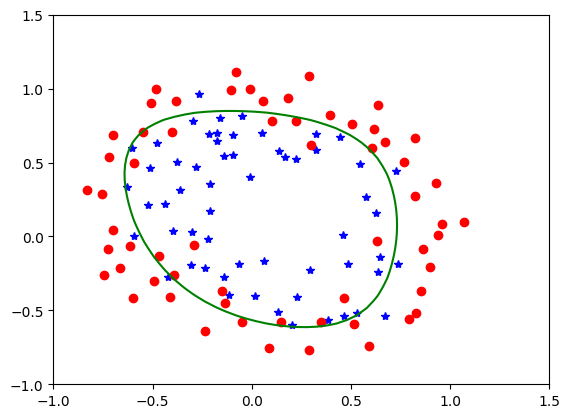

In [37]:
plot_decision_boundary(w, b, X_mapped, y_train)

In [38]:
#Compute accuracy on the training set
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 82.203390


# EXO7

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
# load dataset
X_train, y_train = load_data("data/ex2data1.txt")

In [41]:
### START CODE HERE ###

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

### END CODE HERE ###

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# TEST EXO7

In [42]:
b_sklearn = lr_model.intercept_
w_sklearn = lr_model.coef_
print(f"w = {w_sklearn}, b = {b_sklearn}")

w = [[0.20535491 0.2005838 ]], b = [-25.05219314]


In [43]:
p = lr_model.predict(X_train)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 89.000000


# Softmax Regression

- z : score
- f : probability = sigmoid(z) | for one class
- fk = probability = softmax(zk) | for class k // wk / bk : of class k
- ..
- threshold / argmax(i)   | i : working-on class
- ..
- cost function :
- binary cross entropy loss
- categorical cross entropy loss
- ..
- decision boundary :
- logistic : seperates target class / and other classes
- softmax : seperates between all classes



In [44]:
def load_data():
    X = np.load("data/X_m.npy")
    y = np.load("data/y_m.npy")

    return X, y

# load dataset
X_train, y_train = load_data()

In [45]:
print("Five elements in X_train are:\n", X_train[5:10])
print("Type of X_train:",type(X_train))

Five elements in X_train are:
 [[5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
Type of X_train: <class 'numpy.ndarray'>


In [46]:
print("Five elements in y_train are:\n", y_train[5:10])
print("Type of y_train:",type(y_train))

Five elements in y_train are:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
Type of y_train: <class 'numpy.ndarray'>


In [47]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (150, 4)
The shape of y_train is: (150, 3)
We have m = 150 training examples


In [48]:
def plot_data(X, y):
    # Convert one-hot encoded labels to class indices
    y_class = np.argmax(y, axis=1)

    # Define feature names
    feature_names = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]

    # Create a scatter plot for each pair of features
    plt.figure(figsize=(12, 6))

    # Plot sepal length vs sepal width
    plt.subplot(1, 2, 1)
    for species in range(3):
        plt.scatter(X[y_class == species, 0], X[y_class == species, 1], label=f"Species {species}")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Sepal Length vs Sepal Width")
    plt.legend()

    # Plot petal length vs petal width
    plt.subplot(1, 2, 2)
    for species in range(3):
        plt.scatter(X[y_class == species, 2], X[y_class == species, 3], label=f"Species {species}")
    plt.xlabel(feature_names[2])
    plt.ylabel(feature_names[3])
    plt.title("Petal Length vs Petal Width")
    plt.legend()

    plt.tight_layout()
    plt.show()

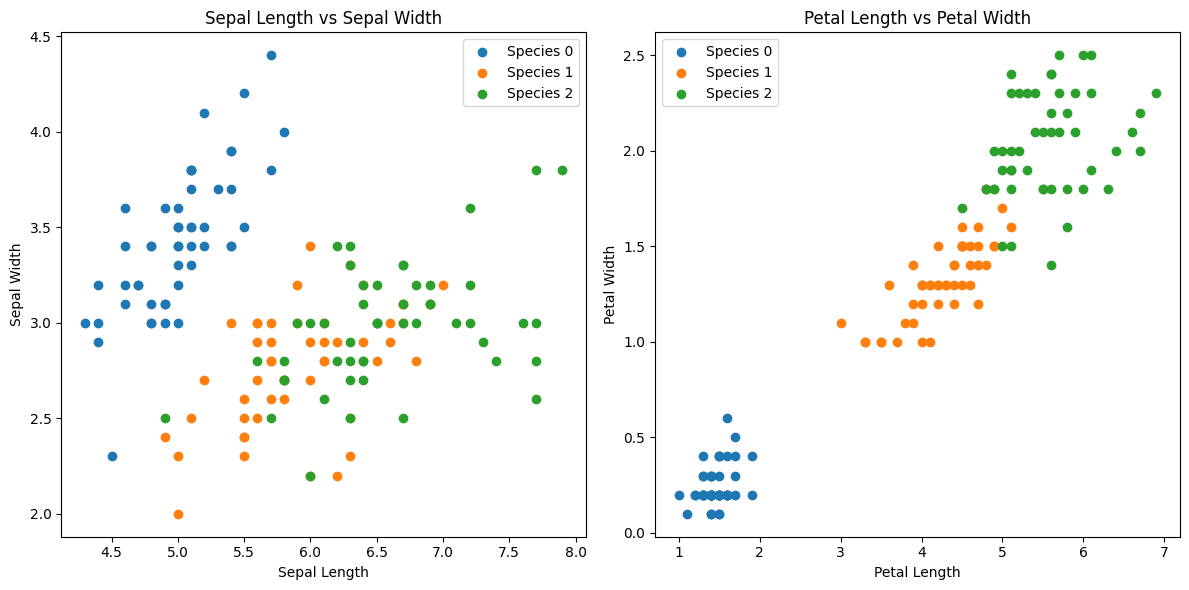

In [49]:
plot_data(X_train, y_train)

# EXO8
0: sepal length
1: sepal width
2: petal length
3: petal width

In [50]:
import itertools

# 0: sepal length
# 1: sepal width
# 2: petal length
# 3: petal width

def plot_data_4_features(X, y):

    y_class = np.argmax(y, axis=1)

    feature_names = [
        "Sepal Length",
        "Sepal Width",
        "Petal Length",
        "Petal Width"
    ]

    feature_pairs = list(itertools.combinations(range(4), 2))

    plt.figure(figsize=(15, 8))

    for idx, (i, j) in enumerate(feature_pairs):

        plt.subplot(2, 3, idx + 1)

        for species in range(3):
            plt.scatter(
                X[y_class == species, i],
                X[y_class == species, j],
                label=f"Species {species}"
            )

        plt.xlabel(feature_names[i])
        plt.ylabel(feature_names[j])
        plt.title(f"{feature_names[i]} vs {feature_names[j]}")

        if idx == 0:
            plt.legend()

    plt.tight_layout()
    plt.show()

# TEST EXO8

- 0 : setosa
- 1 : Versicolor
- 2 : Virginica

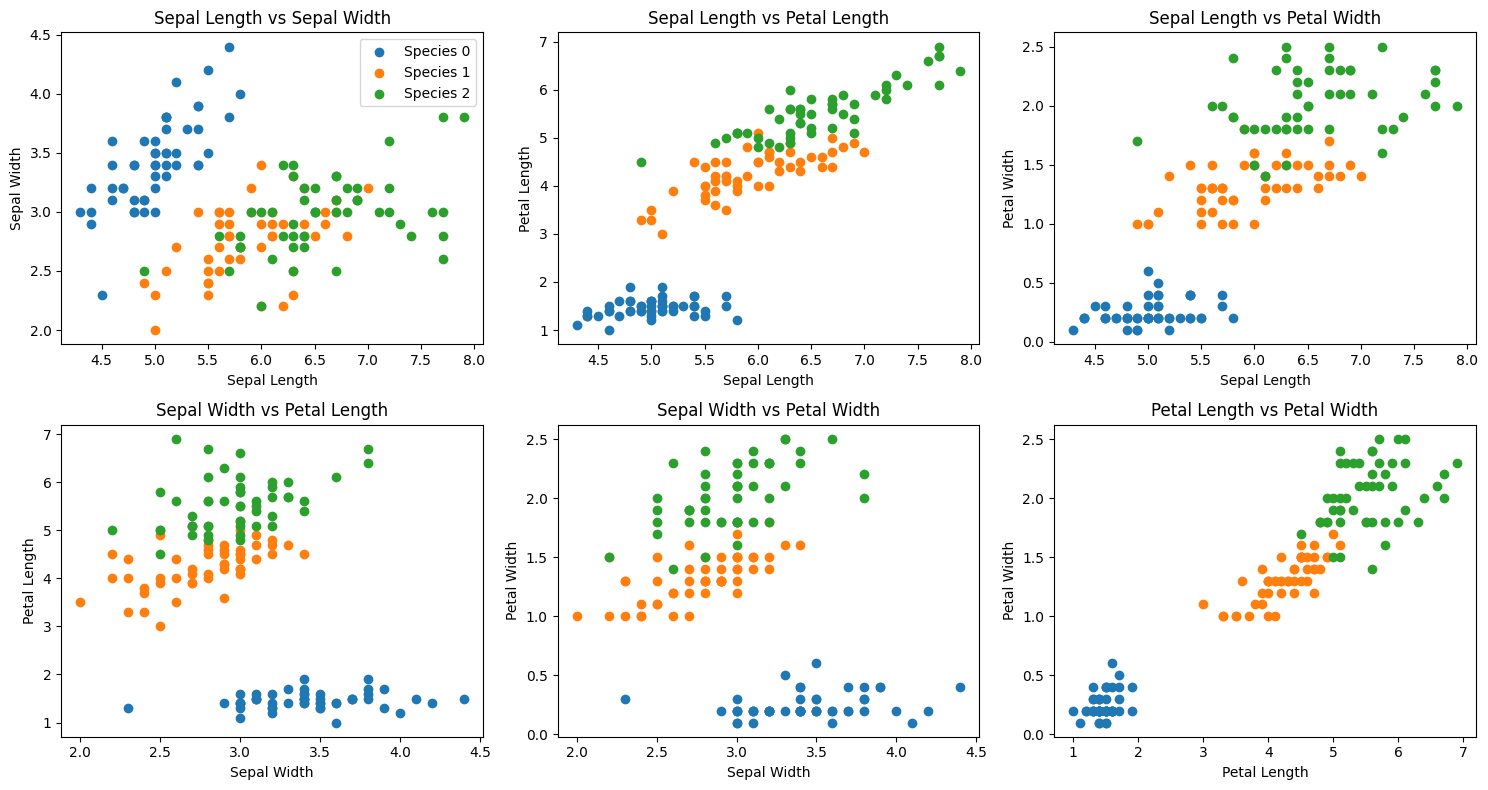

In [51]:
plot_data_4_features(X_train, y_train)

# Obersvations :

- seperations / overlaps + effects on ml model + similar values for f1,f2 for cluster c1,c2

- cluster of setosa is seperated on other clusters in all plots -> easy classification
- clusters of veriscolor and virginica are slighlty overlaped -> plot 1 : sepal length + sepal width have similar values for both veriscolor and virginica -> hard classification

# EXO9

In [52]:
def softmax(z):
    ## START CODE HERE ##
    
    exp_z = np.exp(z)

    if np.isscalar(z) or z.ndim == 0:
        return 1.0 # exp_z / exp_z

    elif z.ndim == 1:
        f_wb = exp_z / np.sum(exp_z)
        return f_wb

    else:
        f_wb = exp_z / np.sum(exp_z, axis=1) # for each row
        return f_wb

    ## END CODE HERE ##

# TEST EXO9

In [53]:
print("softmax([ -1, 0, 1, 2]) = " + str(softmax(np.array([-1, 0, 1, 2]))))

z = np.array([
    [2.0, 1.0, 0.1],  # Sample 1
    [1.0, 2.0, 0.1],  # Sample 2
    [0.1, 1.0, 2.0]   # Sample 3
])

print("softmax(z) = " + str(softmax(z)))


softmax([ -1, 0, 1, 2]) = [0.0320586  0.08714432 0.23688282 0.64391426]
softmax(z) = [[0.65900114 0.24243297 0.09856589]
 [0.24243297 0.65900114 0.09856589]
 [0.09856589 0.24243297 0.65900114]]


# EXO10

In [54]:
def compute_cost_softmax(X, y, w, b):
    m, n = X.shape

    ## START CODE HERE ##
    z = np.dot(X, w) + b
    softmax_f = softmax(z)
    loss_f = - np.sum((y * np.log(softmax_f)), axis=1) # for each row
    total_cost = loss_f.sum() / m

    ## END CODE HERE ##

    return total_cost

# TEST EXO10

In [55]:
m, n = X_train.shape
_, K= y_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros([n,K])
initial_b = np.zeros(K)
cost = compute_cost_softmax(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

ValueError: operands could not be broadcast together with shapes (150,3) (150,) 

# EXO11

In [ ]:
def compute_gradient_softmax(X, y, w, b):
    m, n = X.shape

    ## START CODE HERE ##

    z = np.dot(X, w) + b
    softmax_f = softmax(z)
    diff = softmax_f - y
    dj_dw = np.dot(X.T, diff) / m
    dj_db = np.sum(diff, axis=0) / m

    ## END CODE HERE ##

    return dj_db, dj_dw

# TEST EXO11

In [ ]:
dj_db, dj_dw = compute_gradient_softmax(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw}')

dj_db at initial w (zeros):[-3.51570624e-16  1.76895535e-16 -4.14483263e-16]
dj_dw at initial w (zeros):[[ 0.27911111 -0.03088889 -0.24822222]
 [-0.12355556  0.09577778  0.02777778]
 [ 0.76533333 -0.16733333 -0.598     ]
 [ 0.31777778 -0.04222222 -0.27555556]]


# GRADIENT DESCENT :

In [ ]:
def gradient_descent_softmax(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    # number of training examples
    m = len(X)

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in)

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw
        b_in = b_in - alpha * dj_db

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            cost =  cost_function(X, y, w_in, b_in)
            J_history.append(cost)


        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

# TEST GRADIENT DESCENT :

In [ ]:
m, n = X_train.shape
_, K= y_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros([n,K])
initial_b = np.zeros(K)

# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent_softmax(X_train ,y_train, initial_w, initial_b, compute_cost_softmax, compute_gradient_softmax, alpha, iterations)

Iteration    0: Cost     1.09   


Iteration 1000: Cost     0.36   
Iteration 2000: Cost     0.27   
Iteration 3000: Cost     0.22   
Iteration 4000: Cost     0.19   
Iteration 5000: Cost     0.17   
Iteration 6000: Cost     0.16   
Iteration 7000: Cost     0.15   
Iteration 8000: Cost     0.14   
Iteration 9000: Cost     0.13   
Iteration 9999: Cost     0.13   


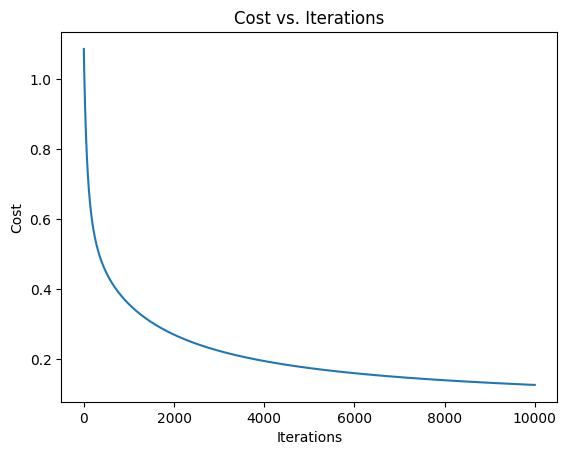

In [ ]:
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs. Iterations")
plt.show()

# EXO12

In [ ]:
def predict_softmax(X, w, b):
    # CODE STARTS HERE

    z = np.dot(X, w) + b
    predictions = softmax(z)

    # CODE ENDS HERE
    return predictions

# TEST EXO12

In [ ]:
#Compute accuracy on our training set
pred = predict_softmax(X_train, w,b)
y_true = np.argmax(y_train, axis=1)
y_pred = np.argmax(pred, axis=1)

# Compute accuracy
print('Train Accuracy: %f'%(np.mean(y_true == y_pred)*100))

Train Accuracy: 98.666667


# why softmax over logistic one vs rest ?

- logistic : sum of probability > 1  |  k models
- softmax : sum of probability = 1  |  1 model